## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from scipy.stats import chi2_contingency
from scipy.stats import kruskal

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix,ConfusionMatrixDisplay, roc_auc_score

## Data Loading

In [ ]:
df = pd.read_csv("Credis_Score_Dataset.csv")

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0xc765,CUS_0xade3,April,Kevin Limx,49,#F%$D@*&8,Entrepreneur,165076.44,NaN,1,6,3,-100,"Personal Loan, and Credit-Builder Loan",11,2,3.71,5.0,Good,712.94,29.051769,18 Years and 2 Months,No,273.174717,1130.5113527934434,Low_spent_Large_value_payments,248.55092985209012,Standard
1,0x1fbf9,CUS_0x7651,April,Slaterv,40,300-72-2019,Manager,57321.36,4666.780,10,10,22,9,"Payday Loan, Payday Loan, Payday Loan, Personal Loan, Student Loan, Mortgage Loan, Mortgage Loan, Personal Loan, and Not Specified",45,14,4.68,7.0,Bad,2224.09,27.436038,NaN,Yes,420.888678,68.80243048143443,High_spent_Medium_value_payments,226.9868910810159,Standard
2,0x15891,CUS_0x84fe,April,Leee,38,579-44-7984,_______,30111.3,NaN,7,5,15,9,"Auto Loan, Mortgage Loan, Personal Loan, Not Specified, Mortgage Loan, Mortgage Loan, Not Specified, Mortgage Loan, and Student Loan",53,19,6.31,14.0,Bad,3075.29,38.259660,4 Years and 2 Months,Yes,140.836626,__10000__,High_spent_Small_value_payments,257.0932938020279,Poor
3,0x3ee7,CUS_0x7620,June,Fionag,24,#F%$D@*&8,Developer,36496.38_,2934.365,8,3,30,3,"Home Equity Loan, Credit-Builder Loan, and Auto Loan",12,18,12.46,10.0,Standard,1328.69,36.750990,NaN,Yes,45.812349,NaN,High_spent_Medium_value_payments,390.7583756600934,Poor
4,0x1e5aa,CUS_0x5572,May,Hyunjoo Jina,39,972-53-4211,Scientist,10068.97,NaN,8,4,7,3,"Payday Loan, Credit-Builder Loan, and Debt Consolidation Loan",29,17,10.8,4.0,Standard,2192.93,28.617576,15 Years and 1 Months,NM,23.222251,46.55878243363996,Low_spent_Medium_value_payments,294.2270494281999,Standard


## Data Understanding and Preprocessing

### Columns in Dataset

In [ ]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

### Check Data Dimension and Data Types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      45058 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42512 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44324 non-null  object 
 14  Delay_

Dataset terdiri dari **50.000 baris dan 28 kolom**. Beberapa **kolom numerik** saat ini disimpan dengan **tipe data object**, padahal **seharusnya integer atau float**. Kolom-kolom tersebut meliputi:
- **Age**
- **Annual_Income**
- **Num_of_Loan**
- **Num_of_Delayed_Payment**
- **Changed_Credit_Limit**
- **Outstanding_Debt**
- **Amount_invested_monthly**
- **Monthly_Balance**

Selain itu, dataset juga memiliki **missing values** pada beberapa kolom yaitu:
- **Name**
- **Monthly_Inhand_Salary**
- **Type_of_Loan**
- **Num_of_Delayed_Payment**
- **Num_Credit_Inquiries**
- **Credit_History_Age**
- **Amount_invested_monthly**
- **Monthly_Balance**

Selain itu, juga ditemukan **kolom yang tidak relevan atau tidak informatif**, seperti **ID, Customer_ID, Name, dan SSN**. Ini merupakan fitur-fitur yang tidak memberikan informasi yang bermakna untuk klasifikasi credit score.

### Check Duplicate

In [ ]:
print("Duplicated Row : " ,df.duplicated().sum())

Duplicated Row :  0


**Tidak ada data duplikat.**

### Check Inconsistent

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols :
  print("Total Unique Values : ", df[col].nunique())
  print(df[col].value_counts())
  print()

Total Unique Values :  50000
ID
0x23c34    1
0x1e2da    1
0x204f6    1
0x18c82    1
0x76d2     1
          ..
0x1e5aa    1
0x3ee7     1
0x15891    1
0x1fbf9    1
0xc765     1
Name: count, Length: 50000, dtype: int64

Total Unique Values :  12443
Customer_ID
CUS_0xae30    8
CUS_0x79c5    8
CUS_0xb8d3    8
CUS_0xa57     8
CUS_0x7e62    8
             ..
CUS_0xbc5e    1
CUS_0x1bde    1
CUS_0x15ad    1
CUS_0x3570    1
CUS_0x7036    1
Name: count, Length: 12443, dtype: int64

Total Unique Values :  8
Month
January     6338
February    6263
March       6258
August      6244
July        6243
June        6239
April       6219
May         6196
Name: count, dtype: int64

Total Unique Values :  10056
Name
Deepa Seetharamanm    29
Vaughanl              24
Nate Raymondw         24
Raymondr              23
Jonathan Stempelr     23
                      ..
Timothyl               1
Danielv                1
Benf                   1
Daniel Satarupau       1
Christoph Steitzs      1
Name: count, Length: 

Pemeriksaan konsistensi data kategorikal menunjukkan adanya nilai tidak valid, data noise, inkonsistensi format, serta variabel numerik yang tersimpan sebagai teks, yang berpotensi menurunkan kualitas data dan kinerja model. **Inkonsistensi data** yang ditemukan :     
- Pada **Occupation** terdapat **'_______'**
- Pada **Credit_Mix** terdapat **'_'**
- Pada **Payment_Behaviour** terdapat **'!@9#%8'**
- Pada **Payment_of_Min_Amount** terdapat **'NM'**   

Nilai-nilai ambigu ini tidak memiliki makna semantik yang jelas dan oleh karena itu nantinya diperlakukan sebagai **missing value**.

- Beberapa fitur numerik yang terdefinisikan sebagai kategorikal (**Age, Annual_Income, Num_of_Loan, Num_of_Delayed_Payment, Changed_Credit_Limit, Outstanding_Debt, Amount_invested_monthly, dan Monthly_Balance**) mengandung inkonsistensi format data. Pada fitur-fitur tersebut ditemukan nilai yang mengandung **karakter '_'**, baik sebagai **nilai tunggal** (yang dapat diinterpretasikan sebagai nilai kosong/missing), maupun **muncul di awal atau akhir nilai numerik**, seperti '**1__**'.

- Selain itu, terdapat **nilai anomali ekstrem** yang jelas **tidak merepresentasikan nilai numerik yang valid**, seperti **'__10000__'** pada **Amount_invested_monthly** dan **'__-333333333333333333333333333__'** pada **Monthly_Balance**. Nilai-nilai tersebut diidentifikasi sebagai noise atau placeholder tidak valid.

### Handling Inconsistencies

#### Handling Invalid Categorical Values

In [ ]:
# Penanganan Nilai Kategorikal Tidak Valid
df['Occupation'] = df['Occupation'].replace('_______', np.nan)
df['Credit_Mix'] = df['Credit_Mix'].replace('_', np.nan)
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].replace('NM', np.nan)
df['Payment_Behaviour'] = df['Payment_Behaviour'].replace('!@9#%8', np.nan)

Nilai seperti **'_______' pada Occupation, '_' pada Credit_Mix, 'NM' pada Payment_of_Min_Amount, dan '!@9#%8' pada Payment_Behaviour** tidak memiliki makna  yang jelas dan **tidak merepresentasikan kategori yang valid**. Oleh karena itu, nilai-nilai tersebut **dijadikan missing values** (NaN) agar dapat ditangani secara sistematis pada tahap imputasi.

#### Handling Extreme Placeholder Values

In [ ]:
# Penanganan Nilai Placeholder Ekstrem
df['Amount_invested_monthly'] = df['Amount_invested_monthly'].replace('__10000__', np.nan)
df['Monthly_Balance'] = df['Monthly_Balance'].replace('__-333333333333333333333333333__', np.nan)

Nilai **'10000' pada Amount_invested_monthly** dan **'-333333333333333333333333333' pada Monthly_Balance** diidentifikasi sebagai **placeholder atau noise ekstrem** yang **tidak realistis**. Nilai-nilai ini tidak merepresentasikan kondisi finansial yang wajar, sehingga **dikonversi menjadi NaN** untuk mencegah distorsi distribusi data dan bias pada model.

#### Normalization of Inconsistent Numeric Formats and Data Type

In [ ]:
# Normalisasi Format Numerik yang Tidak Konsisten
numeric_as_object_cols = ["Age", "Annual_Income", "Num_of_Loan", "Num_of_Delayed_Payment", "Changed_Credit_Limit",
                          "Outstanding_Debt", "Amount_invested_monthly", "Monthly_Balance"]

def clean_numeric_string(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value == "" or value.replace("_", "") == "":
        return np.nan

    value = value.replace("_", "")

    try:
        return float(value)
    except:
        return np.nan

In [ ]:
for col in numeric_as_object_cols:
    df[col] = df[col].apply(clean_numeric_string)

In [ ]:
for col in numeric_as_object_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

Beberapa **fitur numerik yang tersimpan sebagai teks** mengandung karakter **'_'** sebagai bagian dari **format data** (misalnya _1, 1_, atau __). Karakter ini **dihapus dan seluruh nilai dikonversi ke tipe numerik (float)** agar konsisten dan kompatibel dengan proses imputasi.

#### Transformation of Credit_History_Age into a Numeric Representation

In [ ]:
def convert_credit_history_age(x):
    if pd.isna(x):
        return np.nan
    years = re.search(r'(\d+)\s*Years?', x)
    months = re.search(r'(\d+)\s*Months?', x)
    y = int(years.group(1)) if years else 0
    m = int(months.group(1)) if months else 0
    return y * 12 + m

df['Credit_History_Age_Months'] = df['Credit_History_Age'].apply(convert_credit_history_age)

In [ ]:
df.drop(columns=['Credit_History_Age'], inplace=True)

Fitur **Credit_History_Age** disimpan dalam bentuk teks yang menggabungkan informasi tahun dan bulan. Untuk mempertahankan sifat ordinal dan kuantitatif, fitur ini **dikonversi menjadi total bulan** (**Credit_History_Age_Months**) dan kolom asli dihapus untuk menghindari redundansi.

#### Validation and Imputation of Num_of_Loan Using Type_of_Loan

In [ ]:
df['Computed_Num_of_Loan'] = df['Type_of_Loan'].apply(
    lambda x: len([i for i in x.split(', ') if i.strip()])
    if pd.notnull(x) else np.nan
)

invalid_loan_mask = ((df['Num_of_Loan'] < 0) | (df['Num_of_Loan'] > 50))

df.loc[invalid_loan_mask, 'Num_of_Loan'] = np.nan

df['Num_of_Loan'] = df['Num_of_Loan'].fillna(df['Computed_Num_of_Loan'])

In [ ]:
df[['Num_of_Loan', 'Type_of_Loan', 'Computed_Num_of_Loan']]

,Num_of_Loan,Type_of_Loan,Computed_Num_of_Loan
0,2.0,"Personal Loan, and Credit-Builder Loan",2.0
1,9.0,"Payday Loan, Payday Loan, Payday Loan, Personal Loan, Student Loan, Mortgage Loan, Mortgage Loan, Personal Loan, and Not Specified",9.0
2,9.0,"Auto Loan, Mortgage Loan, Personal Loan, Not Specified, Mortgage Loan, Mortgage Loan, Not Specified, Mortgage Loan, and Student Loan",9.0
3,3.0,"Home Equity Loan, Credit-Builder Loan, and Auto Loan",3.0
4,3.0,"Payday Loan, Credit-Builder Loan, and Debt Consolidation Loan",3.0
...,...,...,...
49995,4.0,"Credit-Builder Loan, Auto Loan, Debt Consolidation Loan, and Payday Loan",4.0
49996,0.0,NaN,NaN
49997,3.0,"Personal Loan, Student Loan, and Mortgage Loan",3.0
49998,0.0,NaN,NaN


In [ ]:
# Drop Redundant Feature
df = df.drop(columns=['Type_of_Loan', 'Computed_Num_of_Loan'])

Fitur **Type_of_Loan** merupakan **fitur berbasis teks yang tidak terstruktur dan memiliki jumlah nilai unik yang sangat tinggi, yaitu sebanyak 6.236** nilai unik. Kondisi ini membuat fitur tersebut **kurang efektif** untuk digunakan secara langsung dalam proses pemodelan.

Oleh karena itu, fitur **Type_of_Loan** dimanfaatkan untuk menurunkan informasi jumlah pinjaman sebagai **variabel pembantu untuk memvalidasi dan mengoreksi nilai** pada fitur **Num_of_Loan**. Setelah proses validasi dan koreksi, fitur Type_of_Loan dihapus karena untuk menghindari redundansi.

### Check Invalid Values

In [ ]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months
count,50000.000000,5.000000e+04,42512.000000,50000.000000,50000.000000,50000.000000,49762.000000,50000.000000,46398.000000,48972.000000,48993.000000,50000.000000,50000.000000,50000.000000,45647.000000,49385.000000,45536.000000
mean,111.117960,1.759603e+05,4203.216405,17.086080,22.957140,74.235060,3.540171,21.042240,30.231023,10.356895,27.820995,1420.130504,32.322989,1418.523068,195.872505,402.832099,221.858595
std,688.081324,1.423776e+06,3183.003079,118.287242,130.551021,473.234671,2.465584,14.875604,218.733746,6.780587,194.189624,1146.485099,5.121291,8377.047806,200.044834,213.615802,100.034546
min,-500.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,0.000000,-5.000000,-3.000000,-6.480000,0.000000,0.230000,20.000000,0.000000,0.000000,0.007760,2.000000
25%,24.000000,1.951756e+04,1630.113333,3.000000,4.000000,8.000000,2.000000,10.000000,9.000000,5.320000,3.000000,566.980000,28.083070,30.181528,72.282942,269.834510,145.000000
50%,33.000000,3.784048e+04,3105.010000,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.380000,6.000000,1166.370000,32.342262,69.337833,129.264835,337.402968,220.000000
75%,42.000000,7.302692e+04,5974.963333,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.830000,9.000000,1936.790000,36.536895,160.992411,237.806461,470.059791,303.000000
max,8682.000000,2.419806e+07,15204.633333,1798.000000,1499.000000,5797.000000,50.000000,67.000000,4384.000000,36.970000,2592.000000,4998.070000,50.000000,82331.000000,1944.520747,1576.288935,404.000000


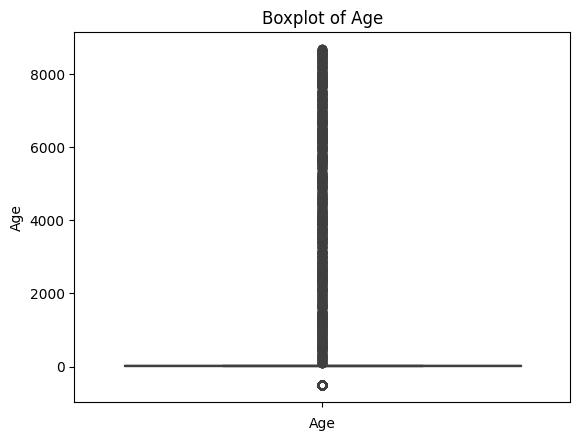

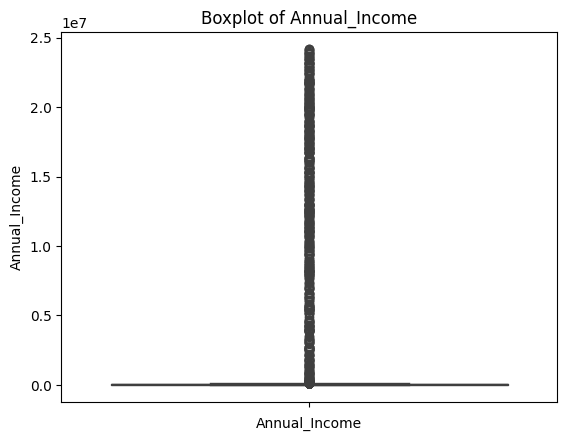

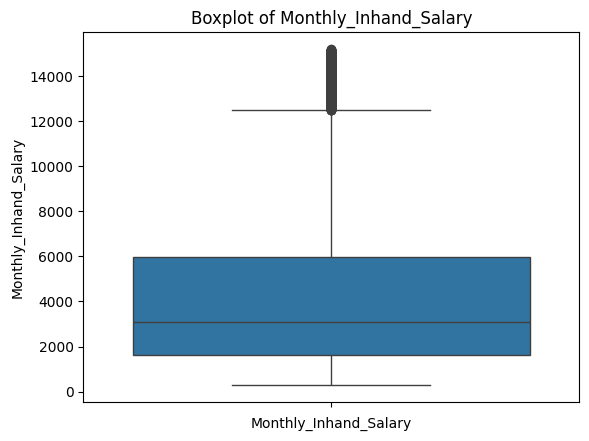

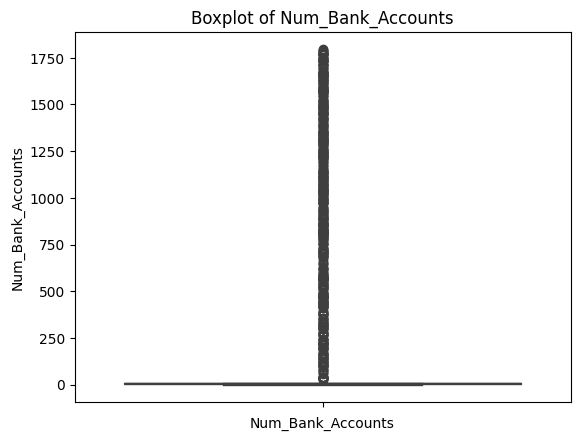

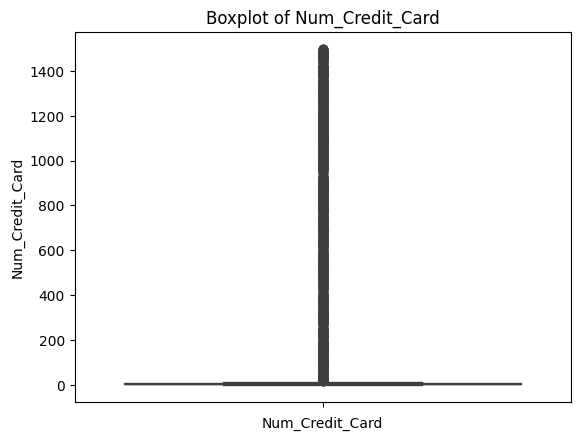

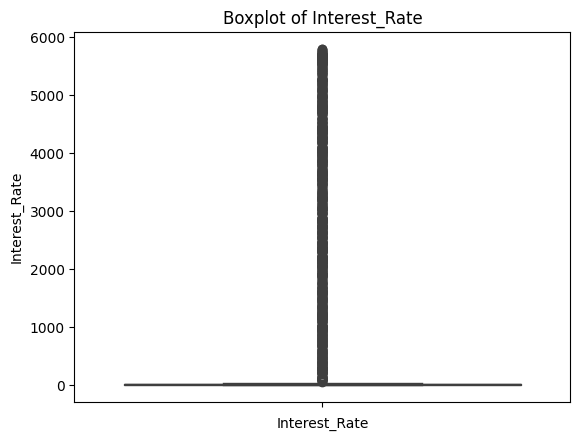

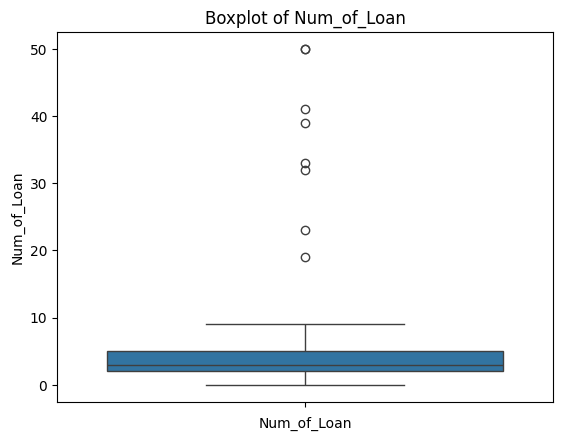

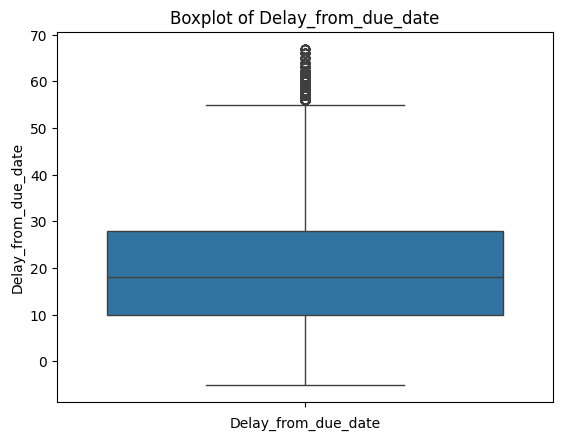

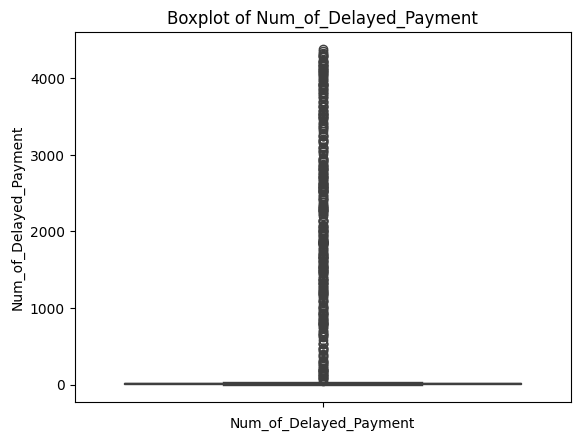

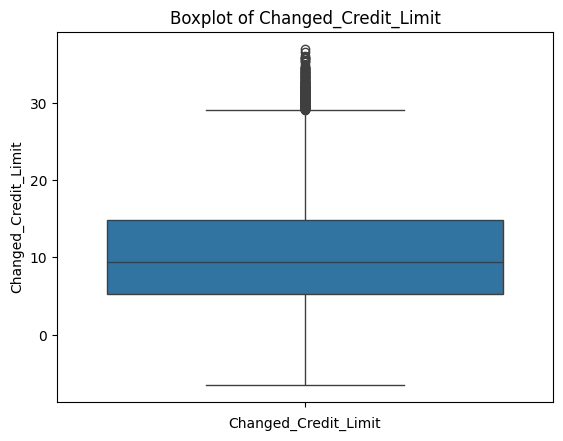

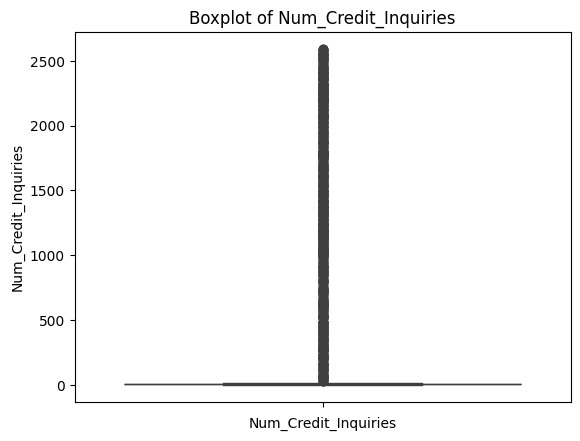

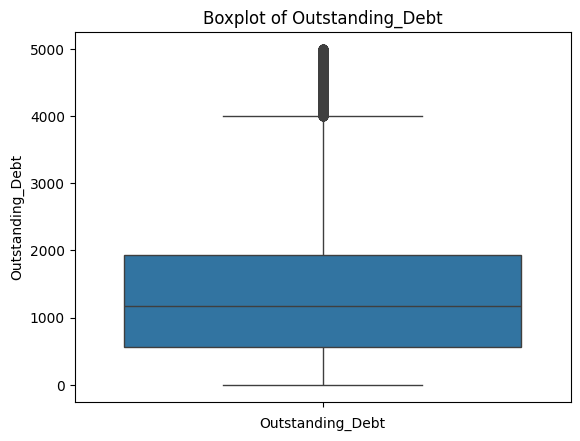

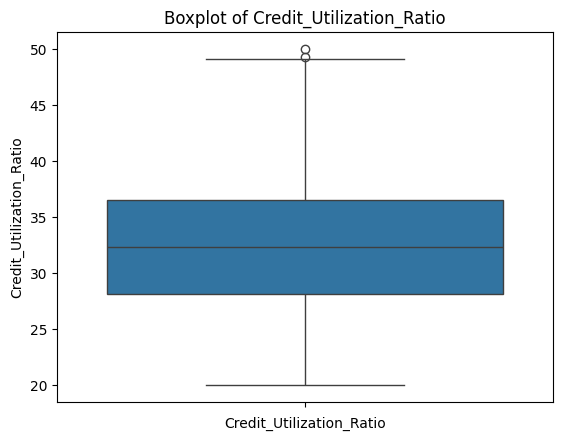

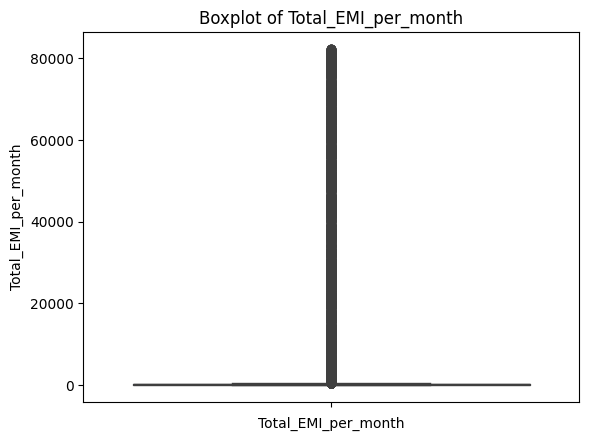

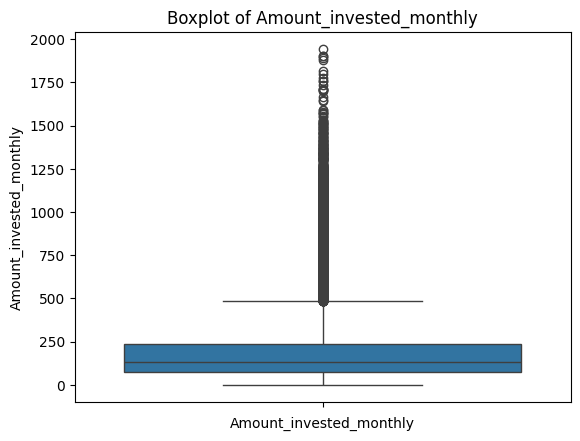

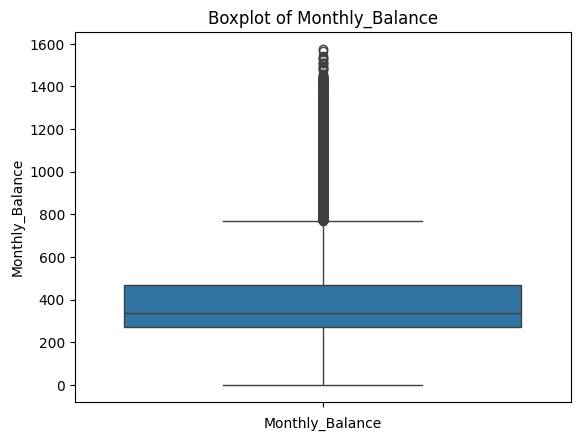

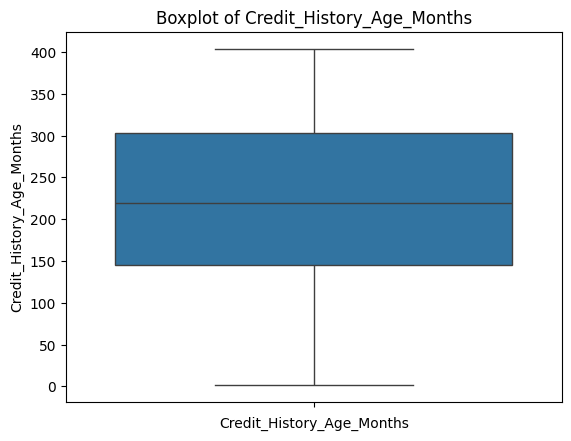

In [ ]:
num_cols = df.select_dtypes(exclude=['object']).columns

for col in num_cols :
  sns.boxplot(y = df[col])
  plt.title(f'Boxplot of {col}')
  plt.xlabel(col)
  plt.show()

Terdapat **nilai numerik yang tidak realistis dan berada di luar batas logis** (invalid values) pada beberapa fitur :     
- **Age** memiliki **nilai minimum -500** dan **maksimum 8682**, yang jelas tidak masuk akal secara demografis.
- **Num_Bank_Accounts** memiliki **nilai negatif dan nilai maksimum yang sangat besar** (hingga ribuan), **jauh di luar batas wajar kepemilikan**.
- **Num_Credit_Card** memiliki **nilai maksimum yang sangat besar** (hingga ribuan), **jauh di luar batas wajar kepemilikan** kartu kredit.
- **Interest_Rate** menunjukkan **nilai maksimum yang sangat ekstrem**, mengindikasikan adanya outlier atau kesalahan pencatatan data.
- **Delay_from_due_date** dan **Changed_Credit_Limit** mengandung **nilai negatif**, yang secara konseptual **tidak valid**.
- **Num_of_Delayed_Payment** menunjukkan **nilai negatif dan nilai maksimum yang sangat tinggi**, yang tidak konsisten dengan definisi variabel.
- **Num_Credit_Inquiries** menunjukkan **nilai maksimum yang sangat tinggi**.
- **Total_EMI_per_month, Amount_invested_monthly, dan Monthly_Balance** memiliki rentang nilai yang sangat lebar dengan standar deviasi tinggi, menandakan keberadaan **outlier ekstrem**.

### Handling Invalid Values

In [ ]:
# Age di bawah 18 -> masih belum bisa melakukan kredit dan Age di atas 100 -> tidak realistis
df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan

# Number of bank accounts < 0 -> tidak bisa negatif dan > 20 -> tidak realistis
df.loc[(df['Num_Bank_Accounts'] < 0) | (df['Num_Bank_Accounts'] > 20), 'Num_Bank_Accounts'] = np.nan

# Number of credit cards > 20 -> tidak realistis
df.loc[df['Num_Credit_Card'] > 20, 'Num_Credit_Card'] = np.nan

# Credit card interest rates > 60 -> bunga sangat ekstrem
df.loc[df['Interest_Rate'] > 60, 'Interest_Rate'] = np.nan

# Delay from due date < 0 -> tidak bisa negatif
df.loc[df['Delay_from_due_date'] < 0, 'Delay_from_due_date'] = np.nan

# Number of delayed payments < 0 -> tidak bisa negatif dan > 60 -> tidak realistis
df.loc[(df['Num_of_Delayed_Payment'] < 0) | (df['Num_of_Delayed_Payment'] > 60), 'Num_of_Delayed_Payment'] = np.nan

# Changed credit limit < 0 -> tidak bisa negatif
df.loc[df['Changed_Credit_Limit'] < 0, 'Changed_Credit_Limit'] = np.nan

# Jumlah credit inquiries > 50 -> nilai sangat ekstrem
df.loc[df['Num_Credit_Inquiries'] > 50, 'Num_Credit_Inquiries'] = np.nan

**Validasi nilai numerik** dilakukan secara selektif hanya pada fitur yang secara empiris terbukti **mengandung nilai tidak masuk akal berdasarkan analisis statistik deskriptif**. Nilai-nilai tersebut ditandai sebagai **missing value (NaN)** untuk mencegah distorsi distribusi data dan memastikan proses imputasi selanjutnya berjalan secara lebih akurat.

### Check Missing Values

In [ ]:
df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,4942
Age,4207
SSN,0
Occupation,3481
Annual_Income,0
Monthly_Inhand_Salary,7488
Num_Bank_Accounts,647


Terdapat **missing values** di fitur **Name, Age, Occupation, Monthly_Inhand_Salary, Num_Bank_Accounts, Num_Credit_Card, Interest_Rate, Num_of_Loan, Delay_from_due_date, Num_of_Delayed_Payment, Changed_Credit_Limit, Num_Credit_Inquiries, Credit_Mix, Payment_of_Min_Amount, Amount_invested_monthly, Payment_Behaviour, Monthly_Balance, Credit_History_Age_Months**.

Jumlah **missing values ini  bertambah** dibandingkan di awal karena telah dilakukan **handling invalid values** (yang banyak **mengubah data menjadi NaN**).

Sebagian besar fitur memiliki jumlah **missing values yang relatif kecil** dibandingkan dengan ukuran keseluruhan dataset, sehingga **teknik imputasi** akan digunakan agar dapat mempertahankan sebanyak mungkin informasi data.

### Handling Meaningless Features

In [ ]:
df = df.drop(columns=["ID", "Customer_ID", "Name", "SSN"])

Fitur **ID, Customer_ID, Name, dan SSN dihapus** karena bersifat **identifier unik dan tidak mengandung informasi prediktif** terhadap Credit_Score.

### Check Target Distribution

In [ ]:
df['Credit_Score'].value_counts(normalize=True)

,proportion
Credit_Score,
Standard,0.53174
Poor,0.28998
Good,0.17828


Distribusi target Credit_Score menunjukkan **ketidakseimbangan kelas (class imbalance)**, di mana kategori **Standard** mendominasi dataset (**±53%**), diikuti oleh **Poor** (**±29%**) dan **Good** (**±18%**). Meskipun ketidakseimbangan ini tidak ekstrem, kondisi tersebut tetap **perlu diperhatikan** karena berpotensi memengaruhi kinerja model, khususnya dalam memprediksi kelas minoritas.

## EDA

### Correlation

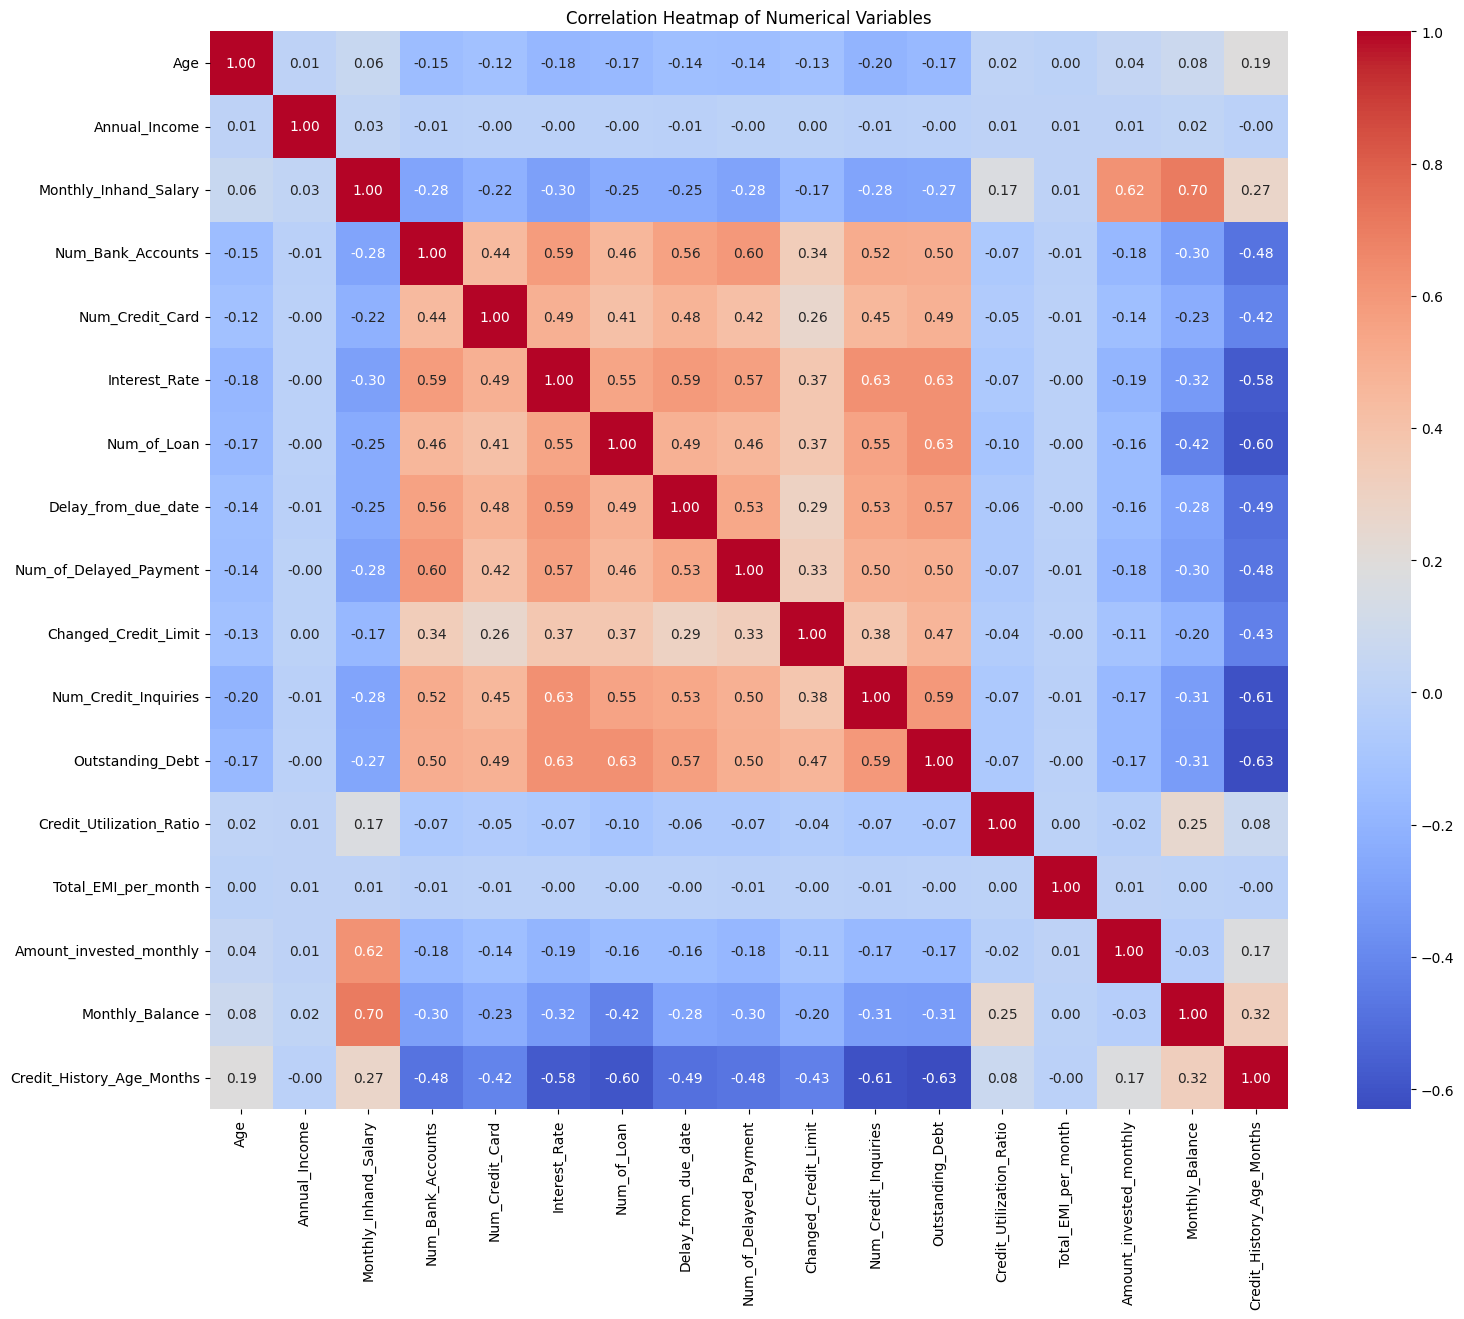

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = num_cols.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", square=True)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [ ]:
df['Annual_Income_log'] = np.log1p(df['Annual_Income'])

In [ ]:
df = df.drop(columns=['Annual_Income'])

Secara umum, matriks korelasi menunjukkan bahwa:
- Sebagian besar fitur memiliki **korelasi rendah hingga moderat, sehingga risiko multikolinearitas berlebihan relatif kecil** dan aman untuk digunakan dalam pemodelan.
- Namun, terdapat **beberapa kelompok fitur dengan korelasi sedang hingga kuat**, khususnya variabel yang berkaitan dengan **perilaku kredit, utang, dan keterlambatan pembayaran**, yang secara logis saling berkaitan.

**A. Kelompok "Beban Kredit dan Risiko"**   
Fitur-fitur berikut menunjukkan **korelasi positif sedang hingga kuat (≈ 0.45–0.65)** satu sama lain:
- **Outstanding_Debt**
- **Num_Credit_Inquiries**
- **Interest_Rate**
- **Num_of_Loan**
- **Delay_from_due_date**
- **Num_of_Delayed_Payment**
- **Num_Bank_Accounts**
- **Num_Credit_Card**    
Pola ini menunjukkan bahwa nasabah dengan **utang yang lebih tinggi** cenderung memiliki **jumlah pinjaman lebih banyak, suku bunga lebih tinggi, lebih sering melakukan credit inquiries, serta lebih sering mengalami keterlambatan pembayaran**. Hubungan ini konsisten dengan **logika domain kredit**, sehingga memperkuat validitas struktur data.

**B. Monthly_Inhand_Salary dan Kapasitas Finansial**   
**Monthly_Inhand_Salary** menunjukkan **korelasi positif yang cukup kuat** dengan:
- **Monthly_Balance (≈ 0.70)**
- **Amount_invested_monthly (≈ 0.62)**   
Hal ini mengindikasikan bahwa nasabah dengan **pendapatan bulanan lebih tinggi** cenderung memiliki **saldo akhir bulanan yang lebih besar** serta **kemampuan investasi yang lebih tinggi**, mencerminkan **fleksibilitas dan stabilitas finansial yang lebih baik**.

**C. Credit_History_Age_Months**   
**Credit_History_Age_Months** memiliki **korelasi negatif yang cukup kuat** dengan:
- **Outstanding_Debt (≈ -0.63)**
- **Num_Credit_Inquiries (≈ -0.61)**
- **Num_of_Loan (≈ -0.60)**
- **Interest_Rate (≈ -0.58)**
- **Delay_from_due_date dan Num_of_Delayed_Payment (≈ -0.48 s.d. -0.49)**   
Artinya, nasabah dengan **riwayat kredit yang lebih panjang** cenderung memiliki **utang lebih rendah, lebih sedikit pinjaman, lebih jarang mengajukan kredit baru, serta tingkat bunga yang lebih rendah**, yang mencerminkan **profil kredit yang lebih matang dan stabil**.

**D. Annual_Income**   
Menunjukkan **korelasi yang sangat lemah (mendekati 0)** dengan hampir seluruh fitur lainnya. Kondisi ini mengindikasikan bahwa **pendapatan tahunan tidak terhubung secara linear** dengan variabel finansial lainnya dalam dataset, kemungkinan disebabkan oleh **distribusi yang sangat skewed, outlier ekstrem, atau ketidakkonsistenan pelaporan nilai**. Oleh karena itu, fitur ini tidak dihapus, tetapi **ditangani melalui transformasi logaritmik** untuk menstabilkan distribusi dan meningkatkan kualitas informasi yang dapat dimanfaatkan oleh model.

### Check Association Between Numerical Variables and Categorical Target Variable

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

results = []

for col in num_cols:
    g_good = df[df['Credit_Score'] == 'Good'][col].dropna()
    g_standard = df[df['Credit_Score'] == 'Standard'][col].dropna()
    g_poor = df[df['Credit_Score'] == 'Poor'][col].dropna()

    if min(len(g_good), len(g_standard), len(g_poor)) > 0:
        h_stat, p = kruskal(g_good, g_standard, g_poor)
        results.append([col, h_stat, p])

kw_df = pd.DataFrame(
    results,
    columns=['Numerical_Feature', 'H_statistic', 'p_value']
).sort_values(by='p_value')

kw_df

,Numerical_Feature,H_statistic,p_value
1,Monthly_Inhand_Salary,1878.151004,0.000000e+00
2,Num_Bank_Accounts,7765.839171,0.000000e+00
3,Num_Credit_Card,7148.689764,0.000000e+00
4,Interest_Rate,11590.743659,0.000000e+00
6,Delay_from_due_date,9546.308896,0.000000e+00
5,Num_of_Loan,6156.178202,0.000000e+00
7,Num_of_Delayed_Payment,6646.061739,0.000000e+00
8,Changed_Credit_Limit,2692.713173,0.000000e+00
14,Monthly_Balance,2476.017693,0.000000e+00
9,Num_Credit_Inquiries,9354.025543,0.000000e+00


Karena **seluruh nilai p-value berada di bawah tingkat signifikansi 0,05**, maka hipotesis nol (H₀) ditolak untuk seluruh variabel numerik. Hal ini menunjukkan bahwa terdapat **perbedaan distribusi yang signifikan secara statistik pada variabel-variabel tersebut di antara kategori Credit_Score** (Good, Standard, dan Poor).

Meskipun **Total_EMI_per_month** memiliki **korelasi linear yang sangat lemah dengan fitur numerik lain**, uji Kruskal–Wallis menunjukkan **perbedaan yang signifikan antar kategori Credit_Score**. Ini berarti pengaruhnya **tidak linear**, tetapi **tetap informatif dan relevan**, sehingga fitur ini tetap dipertahankan dalam model.

### Check Association Between Categorical Variables

In [ ]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

In [ ]:
cat_cols = df.select_dtypes(include=["object"]).columns
cat_cols = [c for c in cat_cols if c not in ["Credit_Score"]]

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)

for col1 in cat_cols:
    for col2 in cat_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cramers_matrix = cramers_matrix.astype(float)

print("Cramer’s V between categorical features")
cramers_matrix.round(2)

Cramer’s V between categorical features


,Month,Occupation,Credit_Mix,Payment_of_Min_Amount,Payment_Behaviour
Month,1.00,0.01,0.01,0.01,0.01
Occupation,0.01,1.00,0.04,0.03,0.02
Credit_Mix,0.01,0.04,1.00,0.82,0.09
Payment_of_Min_Amount,0.01,0.03,0.82,1.00,0.11
Payment_Behaviour,0.01,0.02,0.09,0.11,1.00


Secara umum, **sebagian besar variabel kategorikal menunjukkan hubungan yang sangat lemah satu sama lain** (Cramer’s V < 0,10). Hal ini mengindikasikan **minimnya multikolinearitas** antar fitur kategorikal, yang baik untuk proses pemodelan.

Namun, terdapat **satu hubungan yang sangat kuat**, yaitu:
**Credit_Mix dan Payment_of_Min_Amount (Cramer’s V = 0,82)**. Hubungan ini menunjukkan bahwa **komposisi jenis kredit yang dimiliki nasabah sangat berkaitan dengan pola pembayaran minimum**. Hal ini logis secara domain kredit, karena nasabah dengan kombinasi kredit yang lebih kompleks cenderung memiliki kewajiban pembayaran minimum yang lebih jelas atau konsisten.

### Check Association Between Categorical Variables and Categorical Target Variable

In [ ]:
print("Cramer’s V between categorical features and Credit_Score")

cramer_results = {}

for col in cat_cols:
    cramer_results[col] = cramers_v(df[col], df["Credit_Score"])

cramer_df = pd.DataFrame.from_dict(cramer_results, orient="index", columns=["Cramers_V"])
print(cramer_df.sort_values("Cramers_V", ascending=False).round(3))

Cramer’s V between categorical features and Credit_Score
                       Cramers_V
Payment_of_Min_Amount      0.477
Credit_Mix                 0.454
Payment_Behaviour          0.087
Occupation                 0.033
Month                      0.031


In [ ]:
df = df.drop(columns=["Month", "Occupation"])

Berdasarkan nilai Cramer’s V terhadap Credit_Score, dapat disimpulkan bahwa:
- **Payment_of_Min_Amount (0,477) dan Credit_Mix (0,454)** memiliki **asosiasi moderat hingga kuat** dengan Credit_Score. Artinya, perilaku membayar minimum dan komposisi kredit merupakan faktor kategorikal yang **paling informatif** dalam membedakan kualitas kredit nasabah.
- **Payment_Behaviour (0,087)** memiliki hubungan **lemah**, namun masih menunjukkan sedikit perbedaan pola antar kelas kredit.
- **Occupation (0,033) dan Month (0,031)** menunjukkan **asosiasi yang sangat lemah** dengan Credit_Score, sehingga kontribusinya terhadap prediksi kualitas kredit relatif kecil. Sehingga fitur ini sebaiknya **dihapus** dari dataset untuk **mengurangi noise, menghindari redundansi informasi, dan meningkatkan efisiensi kinerja model prediksi**.

### Distribution

In [ ]:
continuous_cols = ['Age', 'Annual_Income_log', 'Monthly_Inhand_Salary', 'Outstanding_Debt', 'Interest_Rate', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance']
count_cols = ['Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries', 'Delay_from_due_date']

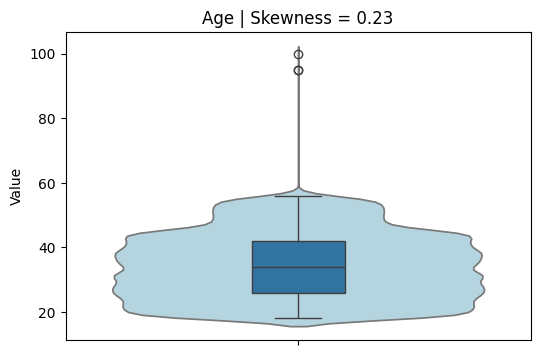

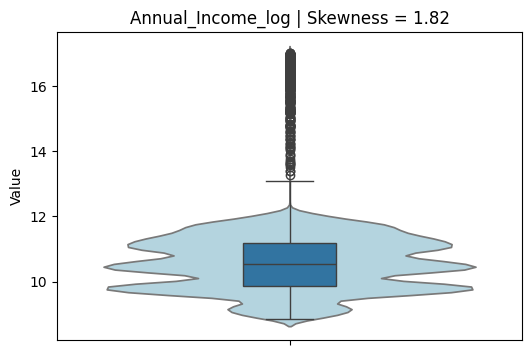

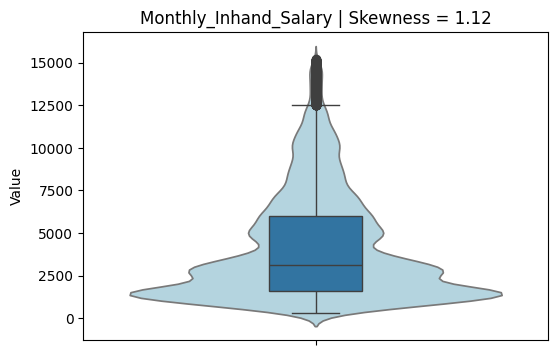

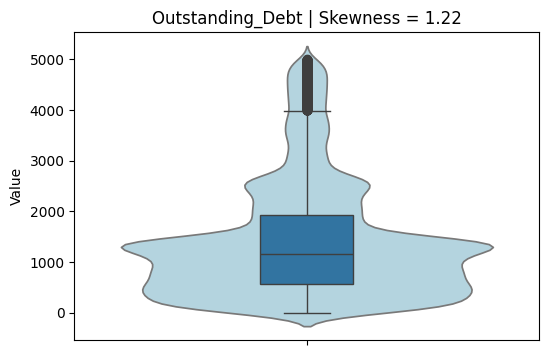

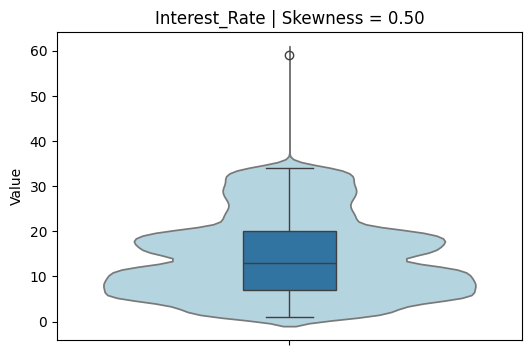

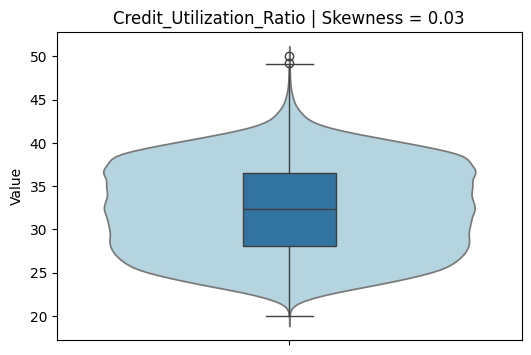

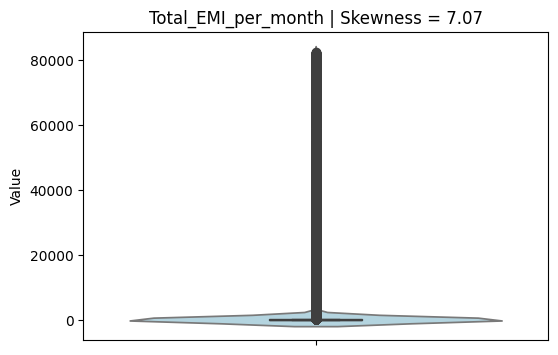

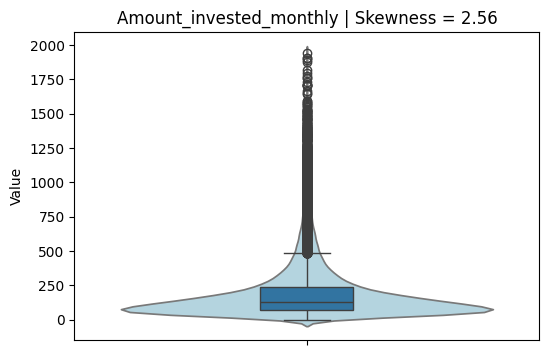

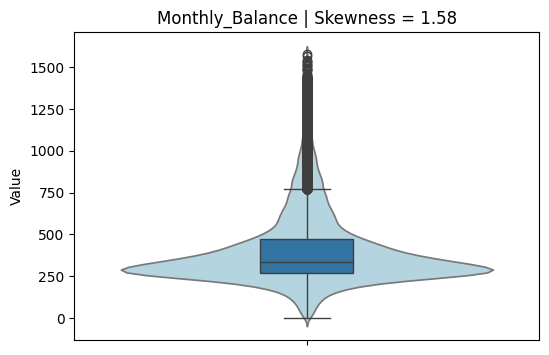

In [ ]:
for col in continuous_cols:
    plt.figure(figsize=(6,4))
    sns.violinplot(y=df[col], inner=None, color="lightblue")
    sns.boxplot(y=df[col], width=0.2)
    plt.title(f"{col} | Skewness = {df[col].skew():.2f}")
    plt.ylabel("Value")
    plt.show()

- Fitur dengan **skewness ekstrem (Total_EMI_per_month, Amount_invested_monthly, Annual_Income_log)** perlu perlakuan khusus sebelum modeling, terutama untuk model sensitif terhadap distribusi.
- Fitur yang **relatif simetris** **(Age, Credit_Utilization_Ratio, Interest_Rate)** **sudah cukup stabil** dan siap digunakan.

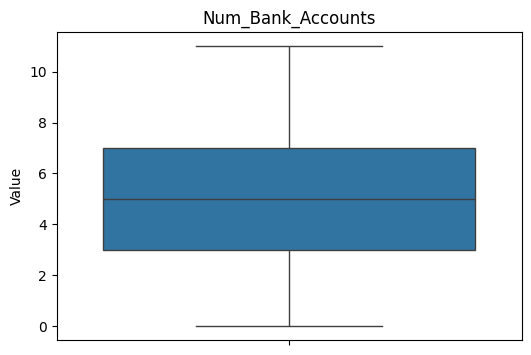

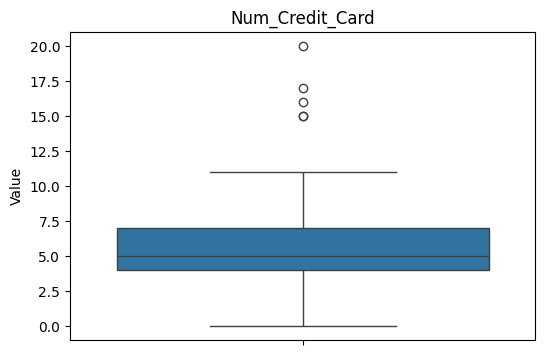

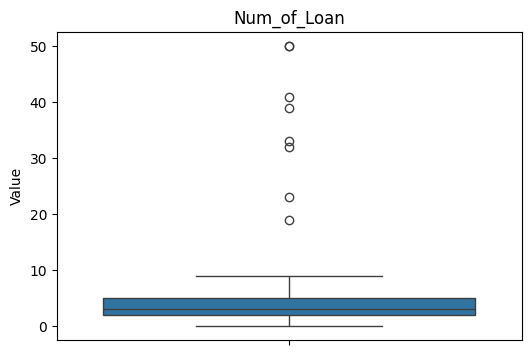

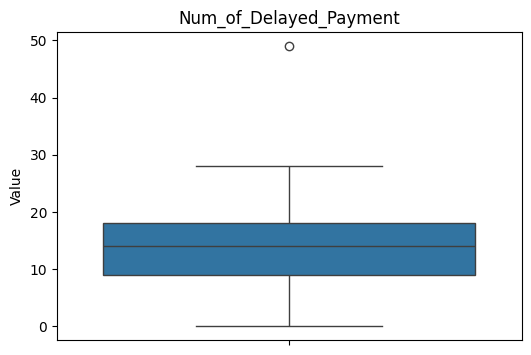

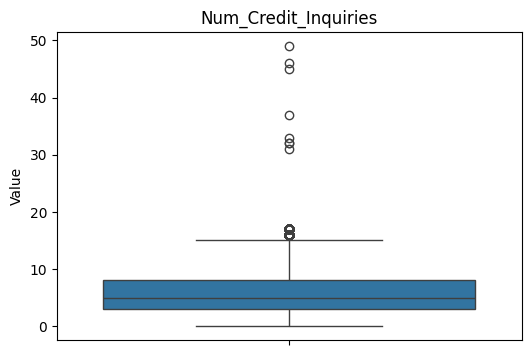

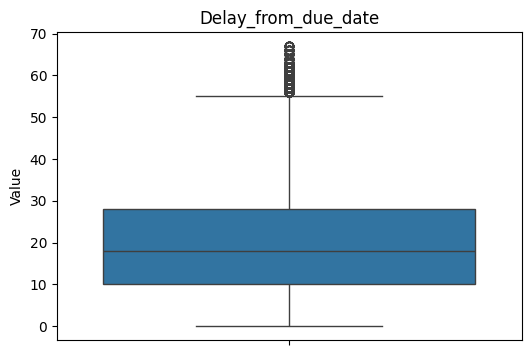

In [ ]:
for col in count_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=df[col])
    plt.title(f"{col}")
    plt.ylabel("Value")
    plt.show()

Terdapat beberapa outiers di fitur  **'Num_Credit_Card'**, **'Num_of_Loan'**, **'Num_of_Delayed_Payment'**, **'Num_Credit_Inquiries'**, dan **'Delay_from_due_date'**. Distribusi secara keseluruhan pada fitur menunjukkan **distribusi bersifat tidak normal**, namun wajar karena ini mencerminkan heterogenitas perilaku kredit dan keterlambatan pembayaran antar nasabah, serta umum ditemukan pada data finansial berbasis hitungan.

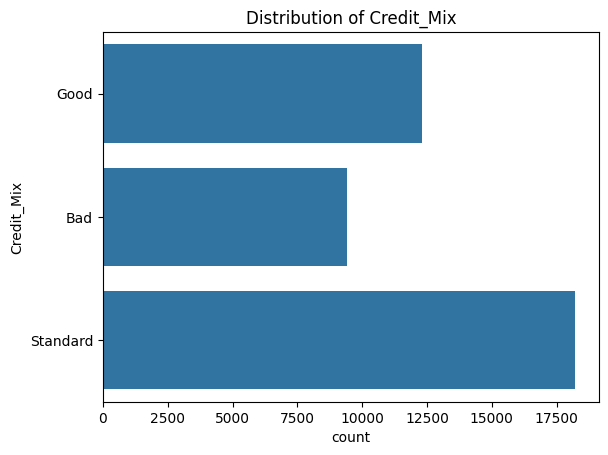

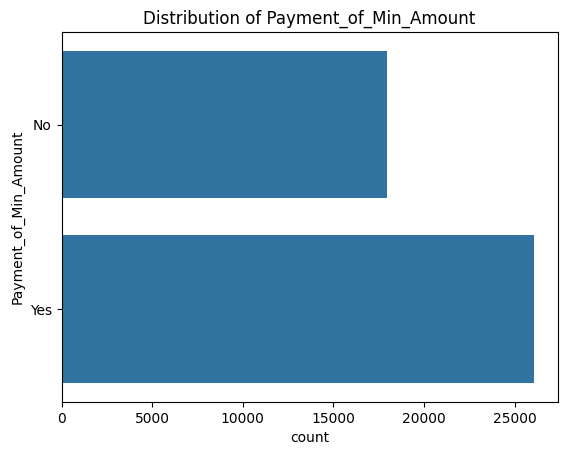

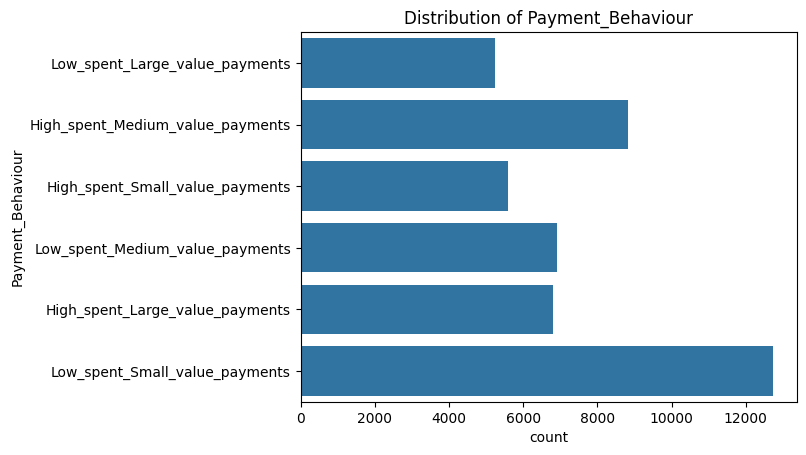

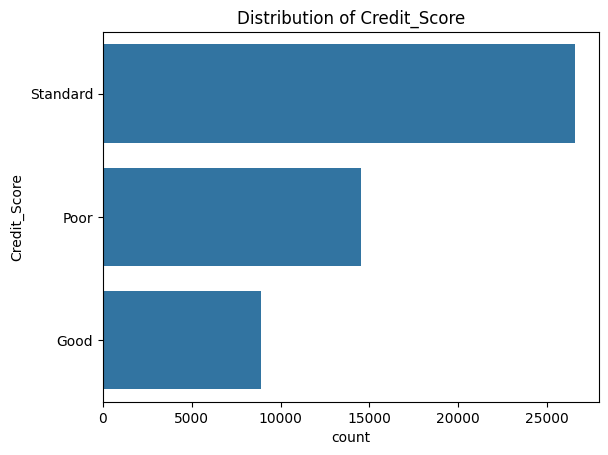

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    sns.countplot(data=df, y=col)
    plt.title(f'Distribution of {col}')
    plt.show()

- **Credit_Mix**   
Pada fitur **Credit_Mix**, kategori **Standard** memiliki **proporsi terbesar**, yang menunjukkan bahwa sebagian besar nasabah berada pada profil kredit tingkat menengah. Sebaliknya, kategori **Bad** memiliki **proporsi paling kecil**, yang mengindikasikan bahwa hanya sedikit nasabah yang berada dalam kondisi kredit yang buruk.

- **Payment_of_Min_Amount**   
Distribusi fitur **Payment_of_Min_Amount** **didominasi oleh kategori Yes**, yang menunjukkan bahwa mayoritas nasabah melakukan pembayaran minimum setiap bulan. Sementara itu, **kategori No muncul dengan frekuensi yang lebih rendah**.

- **Payment_Behavior**   
Fitur **Payment_Behavior** menunjukkan distribusi yang tidak merata. Kategori **Low_spent_Small_value_payments merupakan kategori yang paling umum**, yang mengindikasikan bahwa sebagian besar nasabah melakukan transaksi bernilai kecil dengan tingkat pengeluaran yang relatif rendah. Sebaliknya, kategori **High_spent_Small_value_payments merupakan yang paling jarang**, menunjukkan bahwa hanya sebagian kecil nasabah yang sering melakukan transaksi bernilai kecil namun dengan volume pengeluaran yang tinggi.

- **Credit_Score**   
Distribusi fitur target **Credit_Score** menunjukkan adanya **ketidakseimbangan kelas**, di mana kategori **Standard menjadi kelas mayoritas**, sementara **Good merupakan kelas minoritas** dengan proporsi yang jauh lebih kecil.

## Train Test Split

In [ ]:
x = df.drop(columns=["Credit_Score"])
y = df["Credit_Score"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
x_train.shape

(40000, 20)

In [ ]:
x_test.shape

(10000, 20)

## Handling Missing Values

In [ ]:
x_train.isnull().sum()

,0
Age,3376
Monthly_Inhand_Salary,5942
Num_Bank_Accounts,524
Num_Credit_Card,931
Interest_Rate,818
Num_of_Loan,204
Delay_from_due_date,223
Num_of_Delayed_Payment,3354
Changed_Credit_Limit,1472
Num_Credit_Inquiries,1435


In [ ]:
x_test.isnull().sum()

,0
Age,831
Monthly_Inhand_Salary,1546
Num_Bank_Accounts,123
Num_Credit_Card,243
Interest_Rate,228
Num_of_Loan,34
Delay_from_due_date,66
Num_of_Delayed_Payment,927
Changed_Credit_Limit,387
Num_Credit_Inquiries,385


In [ ]:
num_cols = x_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = x_train.select_dtypes(include=["object"]).columns

### Impute Numerical Missing Values

In [ ]:
num_imputer = SimpleImputer(strategy="median")

x_train[num_cols] = num_imputer.fit_transform(x_train[num_cols])
x_test[num_cols] = num_imputer.transform(x_test[num_cols])

### Impute Categorical Missing Values

In [ ]:
cat_imputer = SimpleImputer(strategy="most_frequent")

x_train[cat_cols] = cat_imputer.fit_transform(x_train[cat_cols])
x_test[cat_cols] = cat_imputer.transform(x_test[cat_cols])

In [ ]:
x_train.isnull().sum().sum()

np.int64(0)

In [ ]:
x_test.isnull().sum().sum()

np.int64(0)

Variabel **numerik** diimputasi menggunakan **median** karena distribusinya tidak normal dan mengandung outlier, sedangkan variabel **kategorikal** diimputasi menggunakan kategori yang paling sering muncul (**modus**).

## Feature Engineering

### Encoding

In [ ]:
# Ordinal Encoding
credit_mix_map = {'Bad': 0, 'Standard': 1, 'Good': 2}
x_train['Credit_Mix'] = x_train['Credit_Mix'].map(credit_mix_map)
x_test['Credit_Mix'] = x_test['Credit_Mix'].map(credit_mix_map)

In [ ]:
# Binary Encoding
x_train['Payment_of_Min_Amount'] = x_train['Payment_of_Min_Amount'].map({'No': 0, 'Yes': 1})
x_test['Payment_of_Min_Amount'] = x_test['Payment_of_Min_Amount'].map({'No': 0, 'Yes': 1})

In [ ]:
# One Hot Encoding
ohe_cols = ["Payment_Behaviour"]
x_train = pd.get_dummies(x_train, columns=ohe_cols, drop_first=True)
x_test = pd.get_dummies(x_test, columns=ohe_cols, drop_first=True)

In [ ]:
x_train, x_test = x_train.align(x_test, join="left", axis=1, fill_value=0)

Variabel **nominal** ditransformasikan menggunakan **one-hot encoding**, variabel **ordinal** dikodekan menggunakan **ordinal mapping** untuk mempertahankan urutan alaminya, dan variabel **biner** dikodekan menggunakan **representasi biner**. Pendekatan ini memastikan bahwa informasi penting tetap terjaga sekaligus kompatibel dengan model berbasis pohon (tree-based models).

In [ ]:
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (40000, 24)
Test shape: (10000, 24)


In [ ]:
x_train.head()

,Age,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months,Annual_Income_log,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
17306,51.0,3355.176667,0.0,1.0,3.0,3.0,8.0,15.0,9.94,4.0,2,311.34,27.262011,0,89.881332,125.189377,370.446957,194.0,10.525759,True,False,False,False,False
10830,41.0,1871.595000,4.0,7.0,11.0,7.0,15.0,16.0,7.83,5.0,1,402.54,35.280421,1,87.233399,64.351066,285.575035,154.0,9.884720,True,False,False,False,False
49668,37.0,3041.425833,3.0,5.0,17.0,4.0,18.0,20.0,19.48,0.0,1,44.59,26.842462,1,11510.000000,183.343017,303.935797,285.0,10.464077,False,False,True,False,False
21923,34.0,482.000417,6.0,9.0,17.0,8.0,61.0,14.0,2.54,6.0,1,2870.92,37.034313,1,42.786179,41.070515,254.343348,40.0,8.881976,False,False,False,False,True
9932,54.0,3258.060000,5.0,5.0,3.0,1.0,10.0,14.0,9.41,8.0,2,724.12,35.307434,0,15.548043,27.185106,523.072851,287.0,10.481945,False,False,False,False,True


In [ ]:
x_test.head()

,Age,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Age_Months,Annual_Income_log,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
47588,23.0,1104.521667,6.0,6.0,6.0,4.0,8.0,20.0,9.11,13.0,1,2187.49,26.234789,1,29.620106,96.660069,264.171991,218.0,9.721681,False,False,False,True,False
38937,34.0,3080.353333,5.0,5.0,10.0,5.0,30.0,14.0,18.27,11.0,1,857.14,29.395115,1,126.478662,146.688352,273.051570,162.0,10.379698,False,True,False,False,False
2611,34.0,663.371667,9.0,9.0,29.0,5.0,16.0,19.0,26.46,11.0,0,3948.86,27.566237,1,27.109995,88.664351,240.562821,90.0,8.934516,False,False,False,False,True
10173,36.0,1263.140833,7.0,3.0,4.0,0.0,18.0,19.0,8.42,4.0,2,517.34,38.172278,0,0.000000,76.443554,339.870529,331.0,9.361403,False,False,False,False,True
35852,33.0,2550.669167,6.0,7.0,18.0,2.0,27.0,18.0,7.28,6.0,1,778.91,34.322817,1,41.843504,67.902100,405.321312,242.0,10.360692,False,True,False,False,False


### Scaling

Meskipun dataset mengandung beberapa **outlier**, **feature scaling tidak diterapkan** karena **Random Forest dan XGBoost** merupakan model berbasis pohon yang **menggunakan pemisahan berdasarkan threshold**, bukan perhitungan berbasis jarak. Model-model ini secara inheren robust terhadap outlier, dan penerapan scaling **tidak akan mengubah urutan relatif nilai fitur** maupun meningkatkan kinerja prediksi model.

## Modeling

### Random Forest

In [ ]:
# Baseline
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(x_train, y_train)
rf_base_pred = rf_base.predict(x_test)

rf_base_proba_train = rf_base.predict_proba(x_train)
rf_base_proba_test = rf_base.predict_proba(x_test)
rf_base_auc_train = roc_auc_score(y_train, rf_base_proba_train, multi_class="ovr", average="macro")
rf_base_auc_test = roc_auc_score(y_test, rf_base_proba_test, multi_class="ovr", average="macro")

print("Confusion matrix :")
print(confusion_matrix(y_test, rf_base_pred))
print("\nClassification Report (Random Forest Baseline) :")
print(classification_report(y_test, rf_base_pred))
print(f"Train AUC (OvR): {rf_base_auc_train:.4f}")
print(f"Test AUC (OvR): {rf_base_auc_test:.4f}")

Confusion matrix :
[[1222   15  546]
 [ 136 2138  626]
 [ 520  584 4213]]

Classification Report (Random Forest Baseline) :
              precision    recall  f1-score   support

        Good       0.65      0.69      0.67      1783
        Poor       0.78      0.74      0.76      2900
    Standard       0.78      0.79      0.79      5317

    accuracy                           0.76     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.76      0.76      0.76     10000

Train AUC (OvR): 1.0000
Test AUC (OvR): 0.8875


**Confusion Matrix**   
Model Random Forest baseline mampu **mengklasifikasikan kelas Standard dengan baik (4213 prediksi benar)**, namun **masih terjadi kesalahan klasifikasi antara kelas Good dan Standard, serta Poor dan Standard**. Hal ini menunjukkan bahwa batas antar kelas masih cukup overlap, terutama pada kelas yang berdekatan secara kualitas kredit.

**Precision, Recall, dan F1-score**
- **Standard** memiliki performa terbaik dengan **F1-score = 0.79**, didukung oleh jumlah data yang dominan.
- **Poor** juga terklasifikasi cukup baik (**F1-score = 0.76**), menunjukkan model mampu mengenali risiko kredit rendah secara konsisten.
- **Good** memiliki performa terendah (**F1-score = 0.67**), yang mengindikasikan model masih kesulitan membedakan nasabah dengan kualitas kredit sangat baik dari kelas lainnya.

**Accuracy**   
Akurasi keseluruhan sebesar **0.76**, yang menunjukkan bahwa sekitar **76% data uji berhasil diklasifikasikan dengan benar**.

**AUC**   
**Train AUC = 1.000**
**Test AUC = 0.8875**   
Nilai **AUC test yang tinggi** menunjukkan kemampuan **pemisahan kelas yang baik**, meskipun **AUC train** yang sempurna mengindikasikan **potensi overfitting ringan**.

#### Hyperparameter Tuning

In [ ]:
rf_param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(x_train, y_train)
print("Best RF Parameters:", rf_grid.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 500}


In [ ]:
rf_best = rf_grid.best_estimator_
rf_best_pred = rf_best.predict(x_test)

rf_best_proba_train = rf_best.predict_proba(x_train)
rf_best_proba_test = rf_best.predict_proba(x_test)
rf_best_auc_train = roc_auc_score(y_train, rf_best_proba_train, multi_class="ovr", average="macro")
rf_best_auc_test = roc_auc_score(y_test, rf_best_proba_test, multi_class="ovr", average="macro")

print("Confusion matrix :")
print(confusion_matrix(y_test, rf_best_pred))
print("\nClassification Report (Random Forest Baseline) :")
print(classification_report(y_test, rf_best_pred))
print(f"Train AUC (OvR): {rf_best_auc_train:.4f}")
print(f"Test AUC (OvR): {rf_best_auc_test:.4f}")

Confusion matrix :
[[1216   10  557]
 [ 125 2152  623]
 [ 504  577 4236]]

Classification Report (Random Forest Baseline) :
              precision    recall  f1-score   support

        Good       0.66      0.68      0.67      1783
        Poor       0.79      0.74      0.76      2900
    Standard       0.78      0.80      0.79      5317

    accuracy                           0.76     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.76      0.76      0.76     10000

Train AUC (OvR): 1.0000
Test AUC (OvR): 0.8903


**Confusion Matrix**   
Secara umum, pola kesalahan klasifikasi **mirip dengan model baseline**. Namun terdapat sedikit **peningkatan prediksi benar pada kelas Standard (4236)**.

**Precision, Recall, dan F1-score**   
**Tidak terdapat peningkatan signifikan** dibandingkan baseline:   
- **Standard: F1-score tetap 0.79**
- **Poor: F1-score tetap 0.76**
- **Good: F1-score tetap di 0.67**    
Hal ini menunjukkan bahwa **tuning tidak memberikan dampak berarti** terhadap performa **klasifikasi per kelas**.

**Accuracy**   
Akurasi **tetap** berada di **0.76**, sama seperti baseline.

**AUC**   
**Train AUC = 1.000**   
**Test AUC = 0.8903**     
Terdapat **peningkatan kecil pada AUC test**, yang menunjukkan **sedikit perbaikan dalam kemampuan pemisahan kelas**.

### XGBoost

In [ ]:
# Baseline
label_mapping = {'Poor': 0, 'Standard': 1, 'Good': 2}
inverse_label_mapping = {v: k for k, v in label_mapping.items()}

y_train_encoded = y_train.map(label_mapping)
y_test_encoded = y_test.map(label_mapping)

xgb_base = XGBClassifier(objective="multi:softprob", eval_metric="mlogloss", random_state=42, use_label_encoder=False)

xgb_base.fit(x_train, y_train_encoded)
xgb_base_pred_encoded = xgb_base.predict(x_test)
xgb_base_pred = pd.Series(xgb_base_pred_encoded).map(inverse_label_mapping)

xgb_base_proba_train = xgb_base.predict_proba(x_train)
xgb_base_proba_test = xgb_base.predict_proba(x_test)
xgb_base_auc_train = roc_auc_score(y_train_encoded, xgb_base_proba_train, multi_class="ovr", average="macro")
xgb_base_auc_test = roc_auc_score(y_test_encoded, xgb_base_proba_test, multi_class="ovr", average="macro")

print("Confusion matrix:")
print(confusion_matrix(y_test, xgb_base_pred))
print("\nClassification Report (XGBoost Baseline):")
print(classification_report(y_test, xgb_base_pred))
print(f"Train AUC (OvR): {xgb_base_auc_train:.4f}")
print(f"Test AUC (OvR): {xgb_base_auc_test:.4f}")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:08:46] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion matrix:
[[1167   22  594]
 [ 140 2036  724]
 [ 540  646 4131]]

Classification Report (XGBoost Baseline):
              precision    recall  f1-score   support

        Good       0.63      0.65      0.64      1783
        Poor       0.75      0.70      0.73      2900
    Standard       0.76      0.78      0.77      5317

    accuracy                           0.73     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.73      0.73      0.73     10000

Train AUC (OvR): 0.9557
Test AUC (OvR): 0.8730


**Confusion Matrix**   
Model XGBoost baseline menunjukkan **kesalahan klasifikasi yang lebih besar dibanding Random Forest**, **terutama** pada kelas **Poor** dan **Good** yang sering diprediksi sebagai Standard.

**Precision, Recall, dan F1-score**   
- **Standard**: masih menjadi kelas terbaik dengan **F1-score = 0.77**
- **Poor** memiliki **F1-score = 0.73**
- **Good** memiliki performa terendah dengan **F1-score = 0.64**    
Secara keseluruhan, performa XGBoost baseline masih berada di bawah Random Forest.

**Accuracy**   
Akurasi sebesar **0.73**, **lebih rendah dibandingkan Random Forest**.

**AUC**   
**Train AUC = 0.9557**   
**Test AUC = 0.8730**     
Nilai **AUC test cukup tinggi**, namun masih **lebih rendah dibandingkan Random Forest**, menunjukkan kemampuan pemisahan kelas yang sedikit lebih lemah.

#### Hyperparameter Tuning

In [ ]:
xgb_param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 6, 9],
    "learning_rate": [0.01, 0.05, 0.1]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        use_label_encoder=False
    ),
    param_grid=xgb_param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(x_train, y_train_encoded)
print("Best XGB Parameters:", xgb_grid.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:52:57] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB Parameters: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 500}


In [ ]:
xgb_best = xgb_grid.best_estimator_
xgb_best_pred_encoded = xgb_best.predict(x_test)
xgb_best_pred = pd.Series(xgb_best_pred_encoded).map(inverse_label_mapping)

xgb_best_proba_train = xgb_best.predict_proba(x_train)
xgb_best_proba_test = xgb_best.predict_proba(x_test)
xgb_best_auc_train = roc_auc_score(y_train_encoded, xgb_best_proba_train, multi_class="ovr", average="macro")
xgb_best_auc_test = roc_auc_score(y_test_encoded, xgb_best_proba_test, multi_class="ovr", average="macro")

print("Confusion matrix : ")
print(confusion_matrix(y_test, xgb_best_pred))
print("\nClassification Report (XGBoost Baseline):")
print(classification_report(y_test, xgb_best_pred))
print(f"Train AUC (OvR): {xgb_best_auc_train:.4f}")
print(f"Test AUC (OvR): {xgb_best_auc_test:.4f}")

Confusion matrix : 
[[1195   16  572]
 [  86 2126  688]
 [ 455  614 4248]]

Classification Report (XGBoost Baseline):
              precision    recall  f1-score   support

        Good       0.69      0.67      0.68      1783
        Poor       0.77      0.73      0.75      2900
    Standard       0.77      0.80      0.78      5317

    accuracy                           0.76     10000
   macro avg       0.74      0.73      0.74     10000
weighted avg       0.76      0.76      0.76     10000

Train AUC (OvR): 1.0000
Test AUC (OvR): 0.8884


**Confusion Matrix**   
Tuning berhasil **meningkatkan jumlah prediksi benar**, khususnya pada kelas **Good** dan **Standard**, serta **mengurangi kesalahan klasifikasi** dari kelas **Poor ke Standard**.

**Precision, Recall, dan F1-score**   
Terjadi **peningkatan** performa yang cukup jelas:
- **Standard: F1-score naik menjadi 0.78**
- **Poor F1-score naik menjadi 0.75**
- **Good F1-score naik menjadi 0.68**    
Hal ini menunjukkan bahwa tuning memberikan dampak positif pada keseimbangan performa antar kelas.

**Accuracy**   
Akurasi meningkat menjadi **0.76**, **setara dengan Random Forest**.

**AUC**   
**Train AUC = 0.9557**   
**Test AUC = 0.8884**     
AUC test **meningkat signifikan** dibanding baseline, menandakan peningkatan kemampuan pemisahan kelas tanpa degradasi performa pada data uji.

## Model Selection

**Kesimpulan:**   
- **Random Forest** menunjukkan performa yang stabil sejak baseline, namun **hyperparameter tuning tidak memberikan peningkatan yang signifikan**.

- **XGBoost** mengalami **peningkatan performa yang lebih jelas setelah tuning**, baik dari sisi accuracy, F1-score, maupun AUC.

- Semua model masih menunjukkan kesulitan dalam mengklasifikasikan kelas **Good**, yang kemungkinan disebabkan oleh **ketidakseimbangan kelas** dan kemiripan karakteristik dengan kelas Standard.

**XGBoost dengan hyperparameter tuning dipilih sebagai model terbaik.** Meskipun Random Forest memiliki tingkat akurasi yang setara, XGBoost menunjukkan **peningkatan performa yang lebih konsisten setelah proses tuning**, terutama pada metrik F1-score dan AUC. Hal ini mengindikasikan bahwa XGBoost memiliki proses pembelajaran yang lebih baik, tidak sekadar menghafal data latih, serta **lebih responsif terhadap optimisasi hyperparameter**.

Sebaliknya, **Random Forest** cenderung telah mencapai performa maksimum sejak model baseline, sehingga **ruang untuk peningkatan performa melalui tuning menjadi lebih terbatas**. Oleh karena itu, dengan mempertimbangkan kemampuan generalisasi dan potensi pengembangan model, XGBoost dipilih sebagai model yang lebih optimal.

## Feature Importance

In [ ]:
xgb_model = xgb_best
importance = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({"Feature": x_train.columns, "Importance": importance}).sort_values(by="Importance", ascending=False)
feature_importance_df.head(10)

,Feature,Importance
10,Credit_Mix,0.393243
13,Payment_of_Min_Amount,0.100684
11,Outstanding_Debt,0.063364
4,Interest_Rate,0.044868
3,Num_Credit_Card,0.035340
2,Num_Bank_Accounts,0.028027
6,Delay_from_due_date,0.023897
8,Changed_Credit_Limit,0.022430
14,Total_EMI_per_month,0.022252
5,Num_of_Loan,0.022007


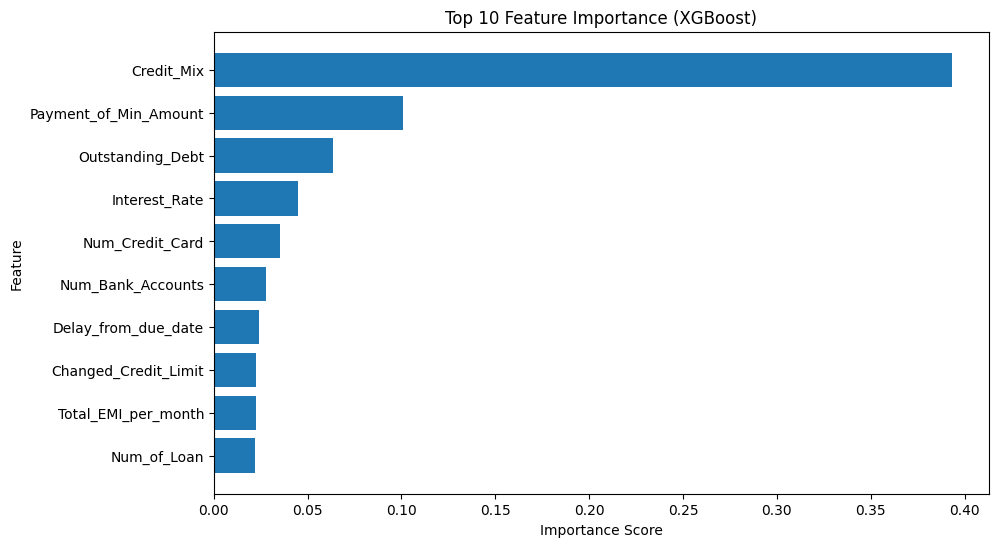

In [ ]:
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance_df["Feature"][:10][::-1],
    feature_importance_df["Importance"][:10][::-1]
)
plt.title("Top 10 Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

Berdasarkan hasil **feature importance model XGBoost (tuned)**, fitur yang paling berpengaruh dalam memprediksi Credit_Score **didominasi oleh variabel yang merepresentasikan kualitas pengelolaan kredit, beban utang, dan perilaku pembayaran nasabah**.

Fitur **Credit_Mix** memiliki kontribusi **paling besar**, menunjukkan bahwa **kombinasi dan keseimbangan jenis kredit merupakan indikator utama** dalam penilaian kelayakan kredit. Selanjutnya, **Payment_of_Min_Amount** dan **Outstanding_Debt** menegaskan bahwa **pola pembayaran minimum dan besarnya utang aktif mencerminkan tingkat tekanan finansial dan risiko gagal bayar**.

Fitur lain seperti **Interest_Rate, Num_Credit_Card, dan Num_Bank_Accounts** berperan dalam menggambarkan eksposur dan **kompleksitas kredit nasabah**. Sementara itu, **Delay_from_due_date, Changed_Credit_Limit, Total_EMI_per_month, dan Num_of_Loan memberikan informasi tambahan** terkait disiplin pembayaran dan beban kewajiban, meskipun kontribusinya relatif lebih kecil.


In [ ]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    xgb_model,
    x_test,
    y_test_encoded,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

perm_df.head(10)

,Feature,Importance
11,Outstanding_Debt,0.08997
4,Interest_Rate,0.07617
6,Delay_from_due_date,0.05518
10,Credit_Mix,0.04164
17,Credit_History_Age_Months,0.04125
8,Changed_Credit_Limit,0.03566
3,Num_Credit_Card,0.03448
14,Total_EMI_per_month,0.02601
5,Num_of_Loan,0.02252
9,Num_Credit_Inquiries,0.02207


**Perbedaan** hasil **feature importance** terjadi karena **metode yang digunakan berbeda**. **Feature importance bawaan XGBoost** mencerminkan **kontribusi fitur selama proses pelatihan**, sedangkan **permutation importance mengukur dampak langsung fitur terhadap performa prediksi model**. Oleh karena itu, fitur seperti **Outstanding_Debt dan Interest_Rate muncul lebih dominan pada permutation importance** karena **perubahan nilainya secara langsung menurunkan akurasi model**. Kedua metode **saling melengkapi dan menunjukkan bahwa prediksi skor kredit dipengaruhi oleh kombinasi struktur kredit dan perilaku keuangan aktual**.